#### Импорты

In [ ]:
!pip install transformers peft accelerate datasets adjustText

In [ ]:
import os
import re
import torch
import numpy as np
from collections import Counter, defaultdict
from time import time
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForMaskedLM,
    DataCollatorForLanguageModeling,
    TrainingArguments,
    Trainer
)
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from adjustText import adjust_text

from sentence_transformers import SentenceTransformer, losses, InputExample
from sentence_transformers.models import Transformer, Pooling
from torch.utils.data import DataLoader
from peft import LoraConfig, get_peft_model, TaskType, PeftModel

from nltk.corpus import stopwords
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download('stopwords')

from nltk.tokenize import sent_tokenize

from datasets import Dataset
from google.colab import drive
import pickle

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### Дообучение

In [ ]:
def get_love_pairs(sentences):
    """Создаёт позитивные пары из контекстов вокруг 'love'"""
    pairs = []
    love_sentences = [s for s in sentences if 'love' in s.lower()]

    # Пары: предложение с 'love' + соседнее предложение
    for i, sent in enumerate(sentences):
        if 'love' in sent.lower():
            if i + 1 < len(sentences):
                pairs.append((sent, sentences[i + 1]))
            if i - 1 >= 0:
                pairs.append((sent, sentences[i - 1]))

    # Пары между собой: все предложения с 'love' похожи
    for i in range(len(love_sentences)):
        for j in range(i + 1, min(i + 5, len(love_sentences))):
            pairs.append((love_sentences[i], love_sentences[j]))

    return pairs

# Якорные пары — синонимы и семантически близкие фразы
anchor_pairs = [
    ("I love you", "I adore you"),
    ("She felt love", "She felt deep affection"),
    ("love and passion", "desire and longing"),
    ("first love", "romantic feeling"),
    ("love is pain", "love brings suffering"),
    ("she loved him", "she desired him"),
    ("feeling of love", "feeling of tenderness"),
    ("love deeply", "care deeply"),
    ("heart full of love", "heart full of longing"),
    ("her love for him", "her devotion to him"),
]

In [ ]:
def load_and_clean_text(filepath):
    """Загружает текст и убирает маркеры глав."""
    with open(filepath, encoding="utf-8") as f:
        text = f.read()

    # Убирает "chapter" и его вариации
    text = re.sub(r'^\s*chapter\b.*$', '', text, flags=re.IGNORECASE | re.MULTILINE)
    text = re.sub(r'^\s*chapter\b.*$', '', text, flags=re.IGNORECASE | re.MULTILINE)

    return text


In [ ]:
def split_into_sentences(text):
    sentences = sent_tokenize(text)
    return [s.strip() for s in sentences if len(s.strip()) > 10]

In [ ]:
rebecca_text = load_and_clean_text("/content/drive/MyDrive/4 course/Rebecca.txt")
rebecca_sentences = split_into_sentences(rebecca_text)

love_pairs = get_love_pairs(rebecca_sentences)
all_pairs = love_pairs + anchor_pairs
print(f"Всего пар: {len(all_pairs)}")
print(f"Пример: {all_pairs[0]}")

In [ ]:
# --- Базовая модель ---
BASE_MODEL = "answerdotai/ModernBERT-base"
word_embedding_model = Transformer(BASE_MODEL, max_seq_length=512)
pooling_model = Pooling(
    word_embedding_model.get_word_embedding_dimension(),
    pooling_mode_mean_tokens=True  # mean pooling для sentence embeddings
)
st_model = SentenceTransformer(modules=[word_embedding_model, pooling_model])

# --- LoRA конфиг (исправленный) ---
lora_config = LoraConfig(
    task_type=TaskType.FEATURE_EXTRACTION,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["Wqkv", "dense"],       # ← добавили dense
    bias="none"
)

# Применяем LoRA к базовой модели трансформера
st_model[0].auto_model = get_peft_model(st_model[0].auto_model, lora_config)
st_model[0].auto_model.print_trainable_parameters()

# --- Датасет ---
train_examples = [InputExample(texts=[a, b]) for a, b in all_pairs]
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=8)

# --- Loss: не нужны метки, негативы строятся из батча ---
train_loss = losses.MultipleNegativesRankingLoss(st_model)

# --- Обучение ---
st_model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=10,
    warmup_steps=50,
    show_progress_bar=True
)


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 1,081,344 || all params: 150,095,616 || trainable%: 0.7204


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,1.921065
1000,1.755691
1500,1.634696
2000,1.576732



   v1 — MLM (Masked Language Modeling), обучение предсказывать замаскированные токены

✓ v2 — Sentence Transformers с MultipleNegativesRankingLoss, обучение на парах предложений из романа

  v3 — Sentence Transformers с MultipleNegativesRankingLoss, обучение на парах предложений из романов (Rebecca, Pride and Prejudice)


In [ ]:
'''Сохранени модели'''

# SAVE_PATH_V3 = "/content/drive/MyDrive/modernbert-rebecca-lora-v3"
# st_model.save(SAVE_PATH_V3)
# print(f"Модель сохранена: {SAVE_PATH_V3}")


Модель сохранена: /content/drive/MyDrive/modernbert-rebecca-lora-v3


In [ ]:
'''
Проверка работы v3 на определении близости слов без контекста.
'''
BASE_MODEL = "answerdotai/ModernBERT-base"
SAVE_PATH = SAVE_PATH_V3

# Загружаем базовую модель
base = AutoModel.from_pretrained(BASE_MODEL)

# Накладываем LoRA-адаптеры явно через PEFT
peft_model = PeftModel.from_pretrained(base, SAVE_PATH)
peft_model.eval()

# Оборачиваем в sentence-transformers
word_embedding_model = Transformer(BASE_MODEL)
word_embedding_model.auto_model = peft_model  # ← подменяем модель

pooling_model = Pooling(
    word_embedding_model.get_word_embedding_dimension(),
    pooling_mode_mean_tokens=True
)
model_loaded = SentenceTransformer(modules=[word_embedding_model, pooling_model])

# Тест
test = model_loaded.encode(["love", "desire", "longing", "affection", "weather", "door"])
from sklearn.metrics.pairwise import cosine_similarity
sims = cosine_similarity([test[0]], test[1:])[0]
words = ["desire", "longing", "affection", "weather", "door"]
for w, s in sorted(zip(words, sims), key=lambda x: -x[1]):
    print(f"{w:15} {s:.4f}")



Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


door            0.8878
longing         0.8391
affection       0.8361
desire          0.8320
weather         0.7774


**Проверка работы v3 на определении близости слов без контекста.**
Результаты:

`door            0.8878`

`longing         0.8391`

`affection       0.8361`

`desire          0.8320`

`weather         0.7774`


Результаты показывают, что модель плохо определяет близость, потому что `door` ближе. Скорее всего из-за того, что в контексте это слово часто встречается рядом с контекстами любви в обоих романах (герои входят в комнаты, объяснения у дверей и т.д.).

Тест не показательный, потому что модель обучалась на предложениях, а не на словах. Однословные запросы теряют контекст.

In [ ]:
test_sentences = [
    "She felt deep love for him",        # якорь
    "Her desire for him was overwhelming", # должно быть близко
    "She longed for his affection",        # должно быть близко
    "The door was made of oak",            # должно быть далеко
    "It was raining and cold outside",     # должно быть далеко
]

embeddings = model_loaded.encode(test_sentences)
sims = cosine_similarity([embeddings[0]], embeddings[1:])[0]
for sent, s in sorted(zip(test_sentences[1:], sims), key=lambda x: -x[1]):
    print(f"{s:.4f}  {sent}")


0.9018  Her desire for him was overwhelming
0.8852  She longed for his affection
0.8450  The door was made of oak
0.8329  It was raining and cold outside


Тест на предложениях показал, что модель правильно разделила семантические группы:

- Любовь/желание/томление — выше (~0.89-0.90)

- Бытовые/нейтральные предложения — ниже (~0.83-0.84)

Разрыв между группами ~0.06 — осмысленное разделение.

In [ ]:
BASE_MODEL = "answerdotai/ModernBERT-base"
SAVED_PATH = "/content/drive/MyDrive/modernbert-rebecca-lora-v2"
#3 версия дообучена только на двух романах, а 2 только на одном, что целесообразно для сравнения с FastText
device = "cuda" if torch.cuda.is_available() else "cpu"

# Загрузка файнтюнутой модели
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
base_model = AutoModel.from_pretrained(BASE_MODEL).to(device)
model = PeftModel.from_pretrained(base_model, SAVED_PATH).to(device)
model.eval()

print("✅ Модель загружена")

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
decoder.bias      | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Модель загружена


#### Функции

In [ ]:
def get_word_vector_in_context(word, sentence, tokenizer, model, device):
    word_lower = word.lower()
    with torch.no_grad():
        encoded = tokenizer(
            sentence,
            return_tensors="pt",
            truncation=True,
            max_length=512,
            return_offsets_mapping=True
        )
        outputs = model(
            input_ids=encoded["input_ids"].to(device),
            attention_mask=encoded["attention_mask"].to(device)
        )
    hidden_states = outputs.last_hidden_state[0].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])

    target_indices = []
    current_word = ""
    current_indices = []
    for i, token in enumerate(tokens):
        if token in ["[CLS]", "[SEP]"]:
            continue
        clean_token = token.replace("##", "")
        if not token.startswith("##"):
            if current_word == word_lower:
                target_indices.extend(current_indices)
            current_word = clean_token
            current_indices = [i]
        else:
            current_word += clean_token
            current_indices.append(i)
    if current_word == word_lower:
        target_indices.extend(current_indices)

    if not target_indices:
        for i, token in enumerate(tokens):
            if word_lower in token.lower():
                target_indices.append(i)

    if target_indices:
        return hidden_states[target_indices].mean(axis=0)
    return None



In [ ]:
def extract_word_contexts(concept_word, sentences, max_contexts=500):
    """
    Находит все предложения, содержащие целевое слово.

    Args:
        concept_word: целевое слово (e.g., 'love')
        sentences: список предложений из текста
        max_contexts: максимальное количество контекстов для анализа

    Returns:
        Список кортежей (предложение, индекс в списке)
    """
    concept_lower = concept_word.lower()
    contexts = []

    for idx, sentence in enumerate(sentences):
        # Простой поиск слова в предложении (с учетом пунктуации)
        if re.search(rf'\b{re.escape(concept_word)}\b', sentence, re.IGNORECASE):
            contexts.append((sentence, idx))
            if len(contexts) >= max_contexts:
                break

    return contexts


In [ ]:
def build_contextual_embeddings(concept_word, sentences, tokenizer, model, device, max_contexts=500):
    """
    Главная функция для построения контекстуальных эмбеддингов.

    Процесс:
    1. Найти все предложения со словом concept_word
    2. Для каждого предложения извлечь вектор concept_word в его контексте
    3. Собрать все векторы в матрицу
    4. Усреднить все векторы → получить "усредненный вектор концепта в романе"

    Returns:
        - word_vectors: матрица всех найденных векторов [num_contexts, 768]
        - contexts: список найденных контекстов (предложений)
        - avg_vector: усредненный вектор концепта [768]
    """

    print(f"\n🔍 Поиск контекстов для '{concept_word}'...")
    contexts = extract_word_contexts(concept_word, sentences, max_contexts)

    print(f"✓ Найдено {len(contexts)} контекстов")

    if len(contexts) == 0:
        print(f"❌ Слово '{concept_word}' не найдено в тексте!")
        return None, [], None

    print(f"📊 Генерация эмбеддингов в контексте...")

    word_vectors = []
    valid_contexts = []

    for i, (sentence, sent_idx) in enumerate(contexts):
        if i % max(1, len(contexts) // 10) == 0:
            print(f"  {i}/{len(contexts)}", end='\r')

        try:
            vec = get_word_vector_in_context(concept_word, sentence, tokenizer, model, device)

            if vec is not None:
                word_vectors.append(vec)
                valid_contexts.append((sentence, sent_idx))

        except Exception as e:
            # Некоторые предложения могут вызвать проблемы (очень длинные, с кодировкой и т.д.)
            continue

    if len(word_vectors) == 0:
        print(f"❌ Не удалось извлечь векторы!")
        return None, [], None

    # Преобразуем в numpy array
    word_vectors = np.array(word_vectors)

    # КЛЮЧЕВОЙ МОМЕНТ: усредняем все векторы
    # Это дает нам "усредненный вектор концепта ИМЕННО В КОНТЕКСТЕ этого романа"
    avg_vector = word_vectors.mean(axis=0)

    # Нормализуем
    avg_vector = avg_vector / (np.linalg.norm(avg_vector) + 1e-9)

    print(f"✓ Обработано {len(word_vectors)} контекстов\n")

    return word_vectors, valid_contexts, avg_vector



In [ ]:
def build_contextual_vocab_embeddings(concept_word, all_sentences, tokenizer, model, device):
    """
    Строит словарь СЛОВ из всего текста (не только из контекстов целевого слова).
    """

    stopwords_set = set(stopwords.words('english'))

    print(f"🔤 Построение контекстного словаря из ВСЕГО текста...")

    # Собираем все слова из ВСЕГО романа
    all_words = Counter()
    for sentence in all_sentences:
        # 👇 ИСПРАВЛЕНИЕ: Просто перебираем строки, без распаковки
        words = re.findall(r"\b[a-z]+(?:'[a-z]+)?\b", sentence.lower())
        for w in words:
            if w not in stopwords_set and len(w) > 2 and w != concept_word.lower():
                all_words[w] += 1

    # Берем top-200 слов по частоте в РОМАНЕ
    top_words = [w for w, c in all_words.most_common(200)]

    print(f"✓ Выбрано {len(top_words)} слов для анализа (из {len(all_words)} уникальных)")

    # Для каждого слова генерируем усредненный вектор
    word2vec_contextual = {}

    print(f"📊 Генерация контекстных эмбеддингов для слов...")

    for word_idx, word in enumerate(top_words):
        if word_idx % max(1, len(top_words) // 10) == 0:
            print(f"  {word_idx}/{len(top_words)}", end='\r')

        # Найти все предложения с этим словом
        word_sentences = [s for s in all_sentences
                          if re.search(rf'\b{re.escape(word)}\b', s, re.IGNORECASE)]

        vectors_for_word = []
        for sent in word_sentences[:50]:  # Берем до 50 контекстов на слово
            try:
                vec = get_word_vector_in_context(word, sent, tokenizer, model, device)
                if vec is not None:
                    vectors_for_word.append(vec)
            except:
                continue

        if vectors_for_word:
            avg_vec = np.array(vectors_for_word).mean(axis=0)
            avg_vec = avg_vec / (np.linalg.norm(avg_vec) + 1e-9)
            word2vec_contextual[word] = avg_vec

    print(f"✓ Получены векторы для {len(word2vec_contextual)} слов\n")

    return word2vec_contextual


def find_semantic_associates(concept_vector, word2vec_contextual, topn=20):
    """
    Находит слова, семантически близкие к концепту в контексте романа.

    Args:
        concept_vector: усредненный вектор концепта (e.g., 'love')
        word2vec_contextual: словарь {слово -> контекстный вектор}
        topn: сколько топ-слов вернуть

    Returns:
        list: [(слово, косинус-сходство), ...]
    """

    similarities = []

    for word, word_vec in word2vec_contextual.items():
        # Косинусное сходство
        cos_sim = np.dot(concept_vector, word_vec)
        similarities.append((word, cos_sim))

    # Сортируем по убыванию
    similarities.sort(key=lambda x: x[1], reverse=True)

    return similarities[:topn]

In [ ]:
def build_contextual_vocab_embeddings(concept_word, all_sentences, tokenizer, model, device):
    """
    Строит словарь СЛОВ из всего текста (не только из контекстов целевого слова).
    """

    stopwords_set = set(stopwords.words('english'))

    print(f"🔤 Построение контекстного словаря из ВСЕГО текста...")

    # Собираем все слова из ВСЕГО романа
    all_words = Counter()
    for sentence in all_sentences:
        # 👇 ИСПРАВЛЕНИЕ: Просто перебираем строки, без распаковки
        words = re.findall(r"\b[a-z]+(?:'[a-z]+)?\b", sentence.lower())
        for w in words:
            if w not in stopwords_set and len(w) > 2 and w != concept_word.lower():
                all_words[w] += 1

    # Берем top-200 слов по частоте в РОМАНЕ
    top_words = [w for w, c in all_words.most_common(200)]

    print(f"✓ Выбрано {len(top_words)} слов для анализа (из {len(all_words)} уникальных)")

    # Для каждого слова генерируем усредненный вектор
    word2vec_contextual = {}

    print(f"📊 Генерация контекстных эмбеддингов для слов...")

    for word_idx, word in enumerate(top_words):
        if word_idx % max(1, len(top_words) // 10) == 0:
            print(f"  {word_idx}/{len(top_words)}", end='\r')

        # Найти все предложения с этим словом
        word_sentences = [s for s in all_sentences
                          if re.search(rf'\b{re.escape(word)}\b', s, re.IGNORECASE)]

        vectors_for_word = []
        for sent in word_sentences[:50]:  # Берем до 50 контекстов на слово
            try:
                vec = get_word_vector_in_context(word, sent, tokenizer, model, device)
                if vec is not None:
                    vectors_for_word.append(vec)
            except:
                continue

        if vectors_for_word:
            avg_vec = np.array(vectors_for_word).mean(axis=0)
            avg_vec = avg_vec / (np.linalg.norm(avg_vec) + 1e-9)
            word2vec_contextual[word] = avg_vec

    print(f"✓ Получены векторы для {len(word2vec_contextual)} слов\n")

    return word2vec_contextual

In [ ]:
def visualize_contextual_semantic_field(concept_word, concept_vector, word2vec_contextual,
                                        valid_contexts, topn=40):
    """
    Визуализирует семантическое поле в контексте романа.

    Отличия от предыдущей версии:
    - Используются контекстные векторы (из реальных предложений)
    - Базовое слово (concept_word) явно выделено
    - Цветовые кластеры имеют смысл в контексте романа
    """

    print(f"\n📊 ПОСТРОЕНИЕ СЕМАНТИЧЕСКОГО ПОЛЯ (в контексте романа)\n")

    # Найти ассоциаты
    associates = find_semantic_associates(concept_vector, word2vec_contextual, topn=topn)
    associate_words = [w for w, _ in associates]

    # Собрать векторы: базовое слово + ассоциаты
    all_words = [concept_word] + associate_words
    all_vectors = np.vstack([concept_vector] + [word2vec_contextual[w] for w in associate_words])

    print(f"✓ Собрано {len(all_words)} слов для визуализации")

    # === КЛАСТЕРИЗАЦИЯ В 768D ===
    print(f"🔍 K-Means кластеризация в 768D пространстве...")
    n_clusters = max(1, min(6, len(all_words) // 8))
    kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42, verbose=0)
    labels = kmeans.fit_predict(all_vectors)

    print(f"✓ Инерция: {kmeans.inertia_:.2f}, кластеров: {n_clusters}")

    # === t-SNE РЕДУКЦИЯ ===
    print(f"🎨 t-SNE редукция до 2D...")
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=min(30, len(all_vectors) - 1),
        learning_rate=200,
        verbose=0,
    )
    vectors_2d = tsne.fit_transform(all_vectors)

    # === ГРАФИК ===
    fig, ax = plt.subplots(figsize=(24, 20))

    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

    # Рисуем все точки
    for cluster_id in range(n_clusters):
        mask = labels == cluster_id
        cluster_points = vectors_2d[mask]
        cluster_words_list = [all_words[i] for i in range(len(all_words)) if mask[i]]

        sizes = [500 if w == concept_word else 150 for w in cluster_words_list]

        ax.scatter(
            cluster_points[:, 0], cluster_points[:, 1],
            c=[colors[cluster_id]] * len(cluster_points),
            s=sizes,
            alpha=0.7,
            edgecolors='black',
            linewidth=0.8,
            label=f'Кластер {cluster_id}'
        )

    # Добавляем текстовые метки
    texts = []
    for i, w in enumerate(all_words):
        x, y = vectors_2d[i]

        if w == concept_word:
            t = ax.text(
                x, y, w.upper(),
                fontsize=14, fontweight='bold',
                bbox=dict(
                    facecolor='yellow', alpha=0.95,
                    edgecolor='red', boxstyle='round,pad=0.6', linewidth=3
                ),
                ha='center', va='center'
            )
        else:
            t = ax.text(
                x, y, w,
                fontsize=12,
                bbox=dict(
                    facecolor='white', alpha=0.85,
                    edgecolor='gray', boxstyle='round,pad=0.3'
                ),
                ha='center', va='center'
            )
        texts.append(t)

    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

    ax.set_title(
        f"Лексико-семантическое поле '{concept_word}'\n"
        f"(Контекстные эмбеддинги ModernBERT, K-Means + t-SNE)",
        fontsize=18, fontweight='bold', pad=20
    )
    ax.set_xlabel("t-SNE dim 1", fontsize=12)
    ax.set_ylabel("t-SNE dim 2", fontsize=12)
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # === СТАТИСТИКА ===
    print(f"\n📈 Top-20 ассоциатов к '{concept_word}' (в контексте романа):\n")
    for i, (w, sim) in enumerate(associates[:20], 1):
        cluster_id = labels[all_words.index(w)]
        print(f"{i:2d}. {w:15s} (similarity: {sim:.4f}, cluster: {cluster_id})")

    # === ПРИМЕРЫ КОНТЕКСТОВ ===
    print(f"\n📝 Примеры контекстов слова '{concept_word}' в романе:\n")
    for i, (sentence, _) in enumerate(valid_contexts[:5], 1):
        # Подсвечиваем целевое слово
        highlighted = re.sub(
            rf'\b({re.escape(concept_word)})\b',
            r'>>> \1 <<<',
            sentence,
            flags=re.IGNORECASE
        )
        print(f"{i}. {highlighted}\n")

    return all_words, vectors_2d, labels

#### Получение эмбеддингов и моделирование поля

In [ ]:
# Шаг 1: Получить контекстные эмбеддинги концепта "love"
concept = "love"
word_vectors, contexts, concept_vector = build_contextual_embeddings(
    concept,
    rebecca_sentences,
    tokenizer,
    model,
    device,
    max_contexts=500
)

if concept_vector is None:
    print(f"Ошибка: не удалось обработать слово '{concept}'")
else:
    # Шаг 2: Построить контекстный словарь
    word2vec_contextual = build_contextual_vocab_embeddings(
        concept,
        rebecca_sentences,
        tokenizer,
        model,
        device
    )


    # Шаг 3: Визуализировать семантическое поле
    all_words, vectors_2d, labels = visualize_contextual_semantic_field(
        concept,
        concept_vector,
        word2vec_contextual,
        contexts,
        topn=80
    )

    print("\n✅ Анализ завершен!")


🔍 Поиск контекстов для 'love'...
✓ Найдено 72 контекстов
📊 Генерация эмбеддингов в контексте...
✓ Обработано 72 контекстов

🔤 Построение контекстного словаря из ВСЕГО текста...
✓ Выбрано 200 слов для анализа (из 7602 уникальных)
📊 Генерация контекстных эмбеддингов для слов...


Сохранение усреднённого эмбеддинга слова `love` по всем 72 контекстам в романе и векторов 72 контекстов

**! Не учитывает формы слова, необходимо добавить, потому что в FastText есть предобработка и там все формы приводятся к инфинитиву**

In [ ]:
"""
# Вариант 1 — просто без границы слова справа
if re.search(rf'\blove', sentence, re.IGNORECASE)
# найдёт: love, loved, loves, lovely, beloved...

# Вариант 2 — только словоформы (без lovely, beloved)
if re.search(rf'\blove[sd]?\b', sentence, re.IGNORECASE)
# найдёт: love, loves, loved
"""

In [ ]:
# Сохраняем чтобы не пересчитывать
np.save("/content/drive/MyDrive/love_vector_rebecca.npy", concept_vector)
np.save("/content/drive/MyDrive/word_vectors_rebecca.npy", word_vectors)

# Словарь эмбеддингов
import pickle
with open("/content/drive/MyDrive/word2vec_contextual_rebecca.pkl", "wb") as f:
    pickle.dump(word2vec_contextual, f)

print("✅ Сохранено!")


✅ Сохранено!


In [ ]:
# Загружаем сохранённые эмбеддинги
concept_vector = np.load("/content/drive/MyDrive/love_vector_rebecca.npy")
word_vectors = np.load("/content/drive/MyDrive/word_vectors_rebecca.npy")

with open("/content/drive/MyDrive/word2vec_contextual_rebecca.pkl", "rb") as f:
    word2vec_contextual = pickle.load(f)

print(f"✅ Загружено! concept_vector: {concept_vector.shape}, слов в словаре: {len(word2vec_contextual)}")


✅ Загружено! concept_vector: (768,), слов в словаре: 186


In [ ]:
concept = 'love'

In [ ]:
contexts = extract_word_contexts("love", rebecca_sentences, max_contexts=500)
print(f"Найдено контекстов: {len(contexts)}")

with open("/content/drive/MyDrive/contexts_rebecca.pkl", "wb") as f:
    pickle.dump(contexts, f)

print("✅ Сохранено!")



Найдено контекстов: 72
✅ Сохранено!


Ниже результат кластеризации 80 ближайших слов без фильтрации из 200 наиболее частотных.


📊 ПОСТРОЕНИЕ СЕМАНТИЧЕСКОГО ПОЛЯ (в контексте романа)

✓ Собрано 81 слов для визуализации
🔍 K-Means кластеризация в 768D пространстве...
✓ Инерция: 12.75, кластеров: 6
🎨 t-SNE редукция до 2D...


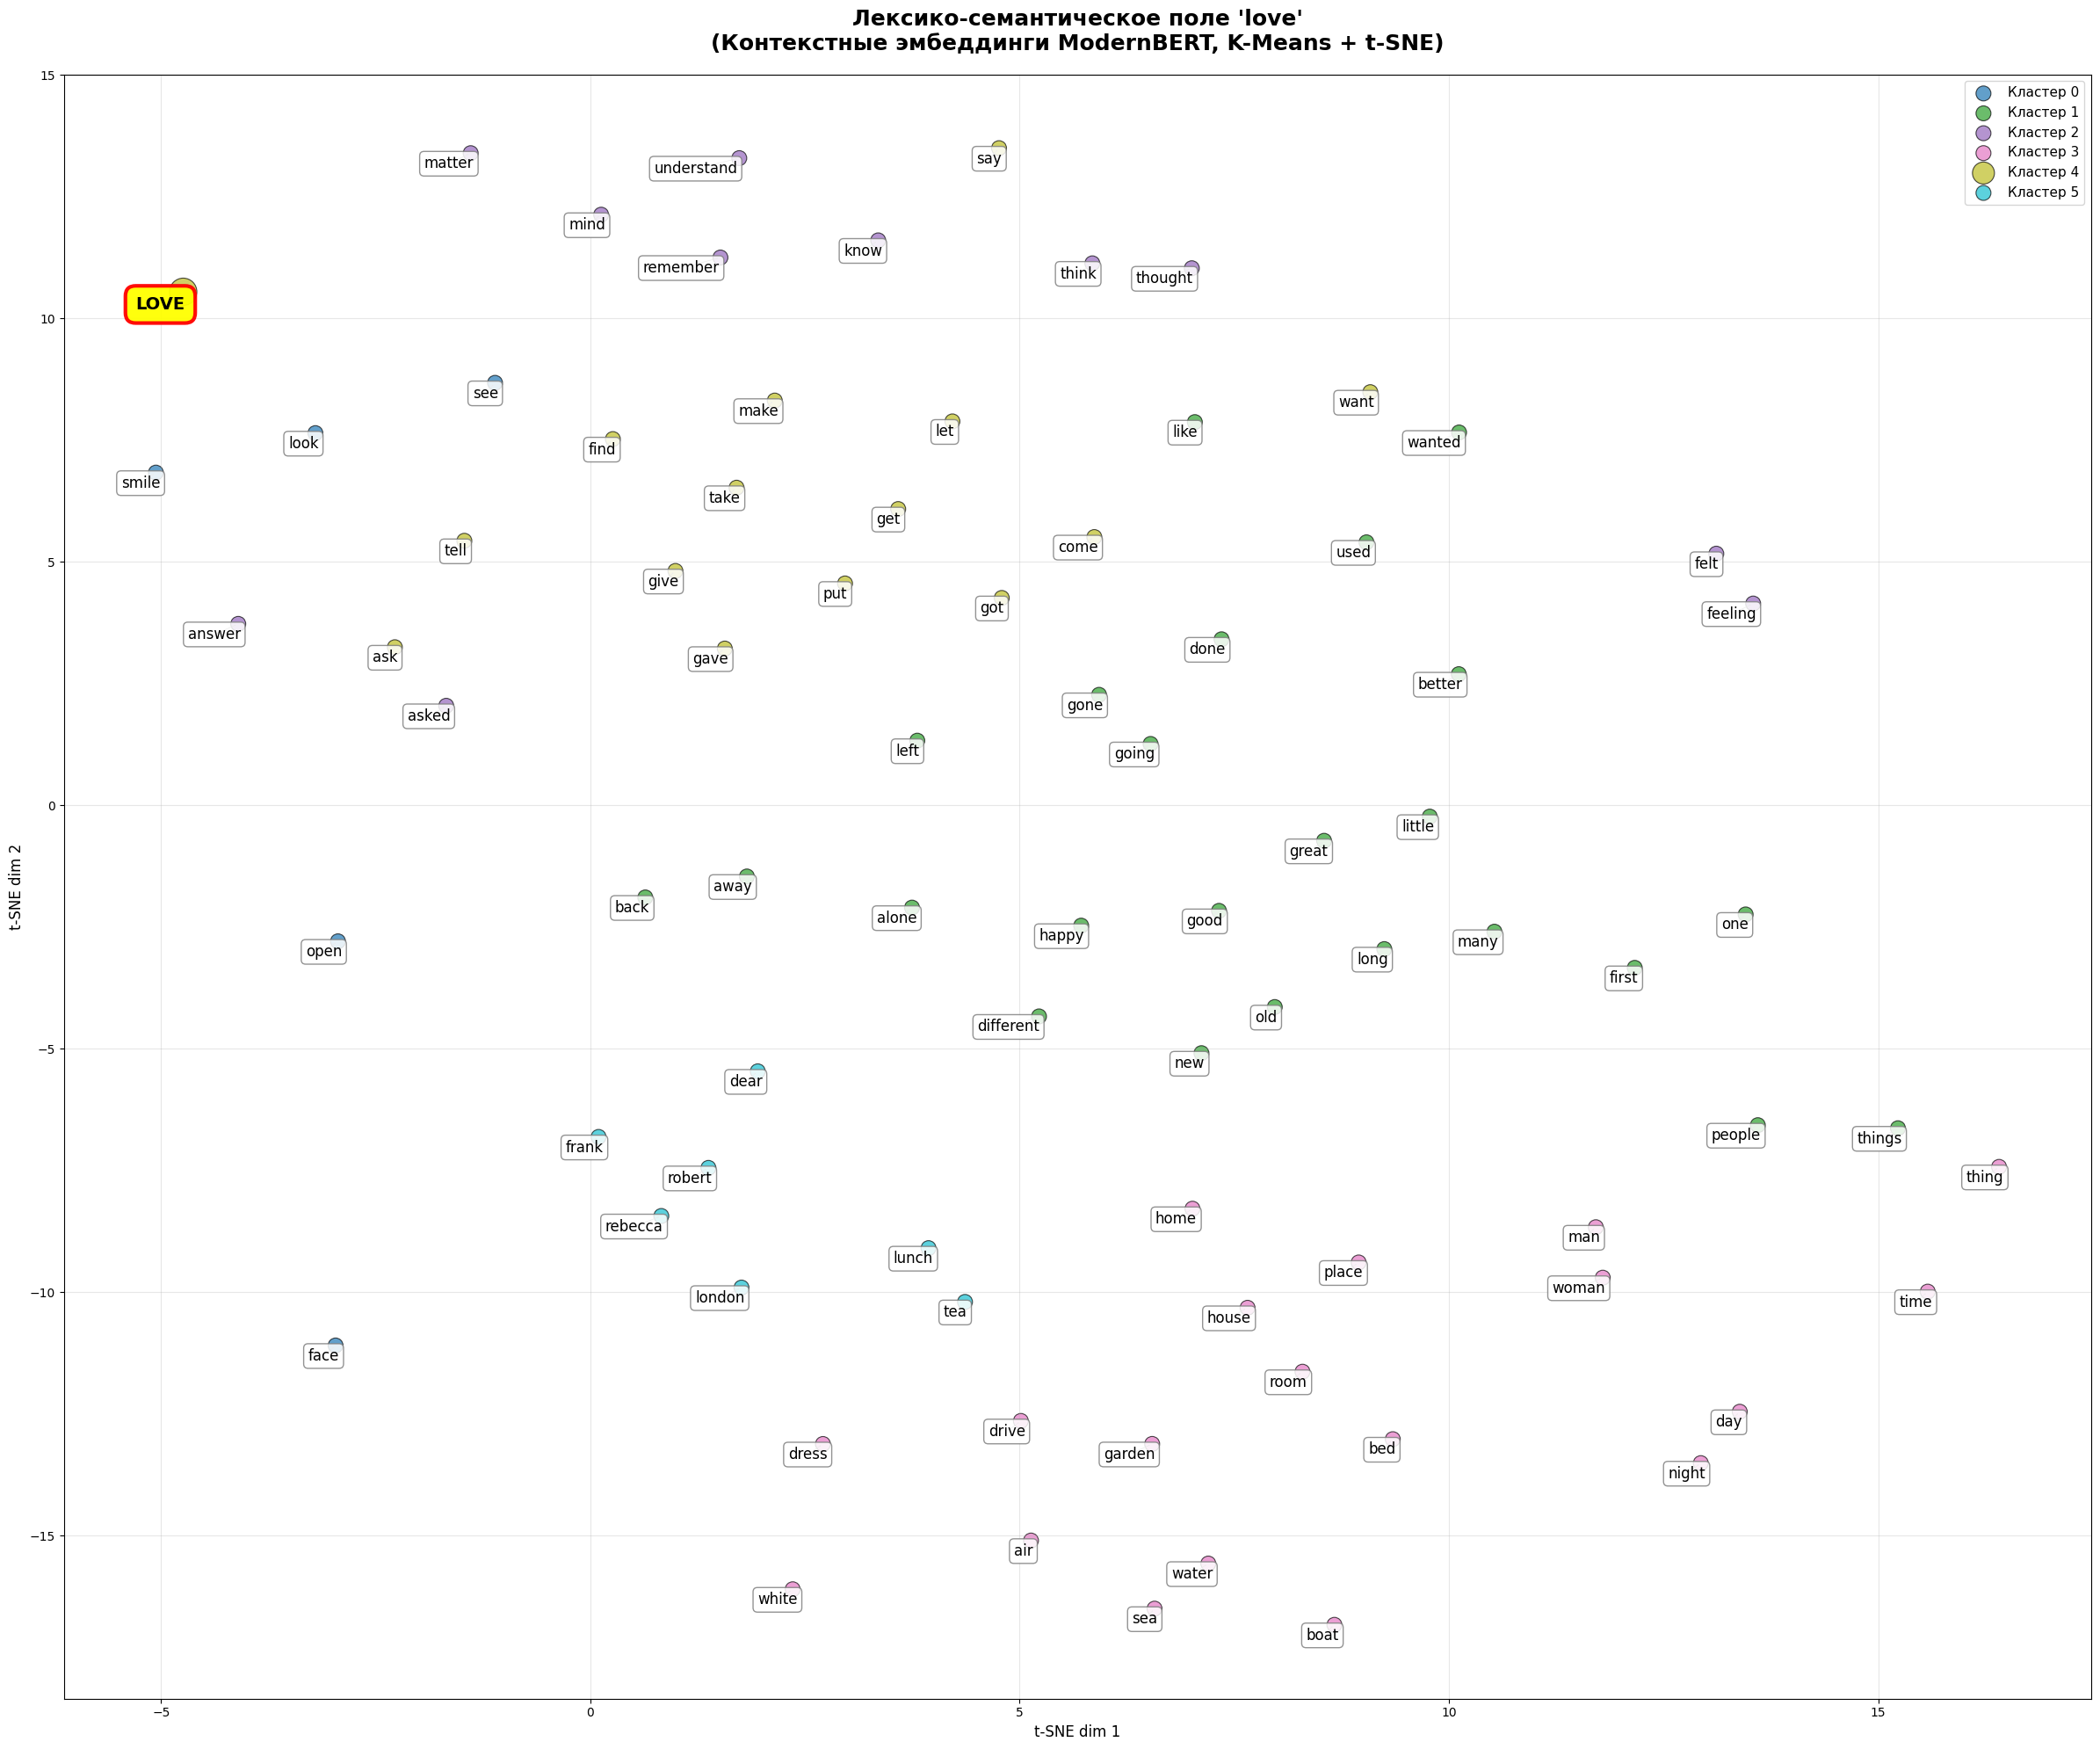


📈 Top-20 ассоциатов к 'love' (в контексте романа):

 1. happy           (similarity: 0.8276, cluster: 1)
 2. give            (similarity: 0.8217, cluster: 4)
 3. get             (similarity: 0.8210, cluster: 4)
 4. take            (similarity: 0.8189, cluster: 4)
 5. look            (similarity: 0.8116, cluster: 0)
 6. good            (similarity: 0.8112, cluster: 1)
 7. home            (similarity: 0.8111, cluster: 3)
 8. old             (similarity: 0.8110, cluster: 1)
 9. mind            (similarity: 0.8086, cluster: 2)
10. want            (similarity: 0.8083, cluster: 4)
11. see             (similarity: 0.8039, cluster: 0)
12. make            (similarity: 0.8025, cluster: 4)
13. ask             (similarity: 0.8018, cluster: 4)
14. new             (similarity: 0.7967, cluster: 1)
15. think           (similarity: 0.7965, cluster: 2)
16. tell            (similarity: 0.7964, cluster: 4)
17. find            (similarity: 0.7954, cluster: 4)
18. dear            (similarity: 0.7951, clust

In [ ]:
# Сразу шаг 3
all_words, vectors_2d, labels = visualize_contextual_semantic_field(
    concept,
    concept_vector,
    word2vec_contextual,
    contexts,   # ← contexts здесь нужен для примеров, можно передать []
    topn=80
)

Метрики и значения

In [ ]:
# Собираем матрицу векторов топ-80 слов
filtered = [(w, l) for w, l in zip(all_words, top_labels) if w in word2vec_contextual]
top_words_list = [w for w, l in filtered]
top_labels_arr = np.array([l for w, l in filtered])
top_vectors = np.array([word2vec_contextual[w] for w in top_words_list])

print(f"Слов: {len(top_words_list)}, меток: {len(top_labels_arr)}, векторов: {len(top_vectors)}")

# 1. Silhouette Score (чем ближе к 1 — тем лучше кластеры)
sil = silhouette_score(top_vectors, top_labels_arr)
print(f"Коэффициент силуэта: {sil:.4f}")

# 2. Davies-Bouldin Index (чем меньше — тем лучше)
db = davies_bouldin_score(top_vectors, top_labels_arr)
print(f"Индекс Дэвиса-Болдина: {db:.4f}")

# 3. Средняя косинусная близость внутри каждого кластера
print("\nСредняя косинусная близость внутри кластеров:")
for cluster_id in sorted(set(top_labels_arr)):
    cluster_vectors = top_vectors[np.array(top_labels_arr) == cluster_id]
    if len(cluster_vectors) > 1:
        sim_matrix = cosine_similarity(cluster_vectors)
        # Берём только верхний треугольник без диагонали
        upper = sim_matrix[np.triu_indices(len(sim_matrix), k=1)]
        print(f"  Кластер {cluster_id}: {upper.mean():.4f} (слов: {len(cluster_vectors)})")

# 4. Косинусная близость каждого кластера к вектору 'love'
print("\nБлизость кластеров к 'love':")
for cluster_id in sorted(set(top_labels_arr)):
    cluster_vectors = top_vectors[top_labels_arr == cluster_id]
    centroid = cluster_vectors.mean(axis=0)
    sim = cosine_similarity([concept_vector], [centroid])[0][0]
    cluster_words = [w for w, l in zip(top_words_list, top_labels_arr) if l == cluster_id]
    print(f"  Кластер {cluster_id} ({', '.join(cluster_words[:3])}...): {sim:.4f}")

Слов: 80, меток: 80, векторов: 80
Коэффициент силуэта: 0.0535
Индекс Дэвиса-Болдина: 2.7156

Средняя косинусная близость внутри кластеров:
  Кластер 0: 0.8178 (слов: 5)
  Кластер 1: 0.8224 (слов: 24)
  Кластер 2: 0.8225 (слов: 11)
  Кластер 3: 0.8218 (слов: 19)
  Кластер 4: 0.8514 (слов: 14)
  Кластер 5: 0.8710 (слов: 7)

Близость кластеров к 'love':
  Кластер 0 (look, see, smile...): 0.8521
  Кластер 1 (happy, good, old...): 0.8566
  Кластер 2 (mind, think, feeling...): 0.8553
  Кластер 3 (home, day, man...): 0.8574
  Кластер 4 (give, get, take...): 0.8574
  Кластер 5 (dear, london, rebecca...): 0.8254


Состав кластеров:

In [ ]:
print("Состав кластеров:\n")
for cluster_id in sorted(set(top_labels_arr)):
    cluster_words = [w for w, l in zip(top_words_list, top_labels_arr) if l == cluster_id]
    print(f"Кластер {cluster_id} ({len(cluster_words)} слов):")
    print(f"  {', '.join(cluster_words)}")
    print()


Состав кластеров:

Кластер 0 (5 слов):
  look, see, smile, face, open

Кластер 1 (24 слов):
  happy, good, old, new, people, left, things, long, great, back, little, done, many, going, gone, away, wanted, like, one, better, used, first, different, alone

Кластер 2 (11 слов):
  mind, think, feeling, answer, know, remember, understand, felt, thought, asked, matter

Кластер 3 (19 слов):
  home, day, man, place, bed, thing, room, sea, house, night, dress, woman, water, air, drive, boat, time, garden, white

Кластер 4 (14 слов):
  give, get, take, want, make, ask, tell, find, come, got, say, let, put, gave

Кластер 5 (7 слов):
  dear, london, rebecca, lunch, robert, tea, frank

